# Orchestration and ML Pipelines  
# 编排 和  机器学习管道

## 一、Training pipeline responsibilities  训练管道职责
### - 1. 下载数据。
### - 2. 转换它，删除无效或极端记录。
### - 3. 准备机器学习的特征和标签。
### - 4. 寻找有用的超参数。
### - 5. 用选定参数训练最终模型。
 
### - 具体步骤取决于问题，但重要的变化是工作流程是明确的。每一步都可以重新运行、检查和替换，而无需重做无关的笔记单元。

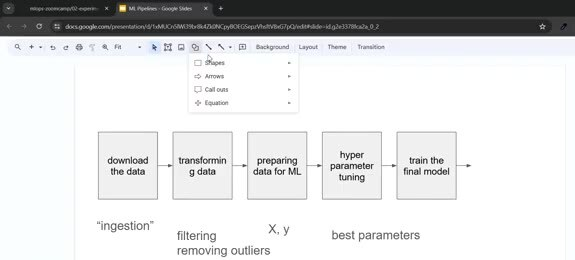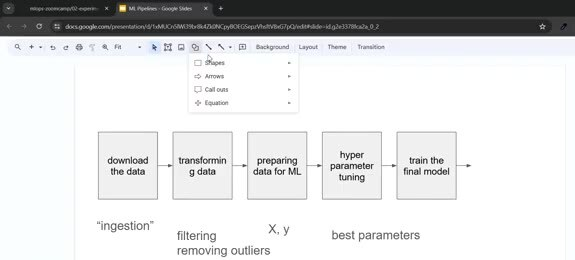

## 二、Pipeline versus orchestration  管道与编排

### 机器学习Pipeline，描述了工作内容及其依赖关系。

### 编排 orchestration 是运行流水线的操作层，负责处理四个操作层面的问题：

- 1. 调度运行并传递参数；
- 2. 记录状态并重试失败任务；
- 3. 支持历史数据回填。

### 从 Python 函数开始，然后将其连接到 Airflow 或 Prefect 等编排工具。Dagster、Kestra 和 Mage 也是可选方案。

### 我们希望实现一个可执行、可复现且支持参数化的流程。
### 例如，训练运行应接收指定的数据周期，而不是使用笔记本会话中恰好存在的文件。

## 三、 一个有用的边界  
### 1. 将数据准备、特征工程、模型选择和最终训练分别封装为独立的函数。
### 2. 每个阶段都需要清晰的API，以便能够独立地测试各个阶段。
### 3. 在下一单元中，我们将应用这一边界，将现有的笔记本转换为命令行脚本。

## 四、Turning the Notebook into a Python Script

### 模块2的notebook，适用于探索性工作，但生产流程需要一个稳定的入口点。
### 我们将它重构为一个Python脚本，可从终端、调度器或编排器中调用。

### 1. Keep the useful code, remove the session state 

### python脚本，已经写在  /mnt/d/develop/mlops/mlops/code/duration_prediction.py  这个地方

### 2. 这是脚本运行情况截图：

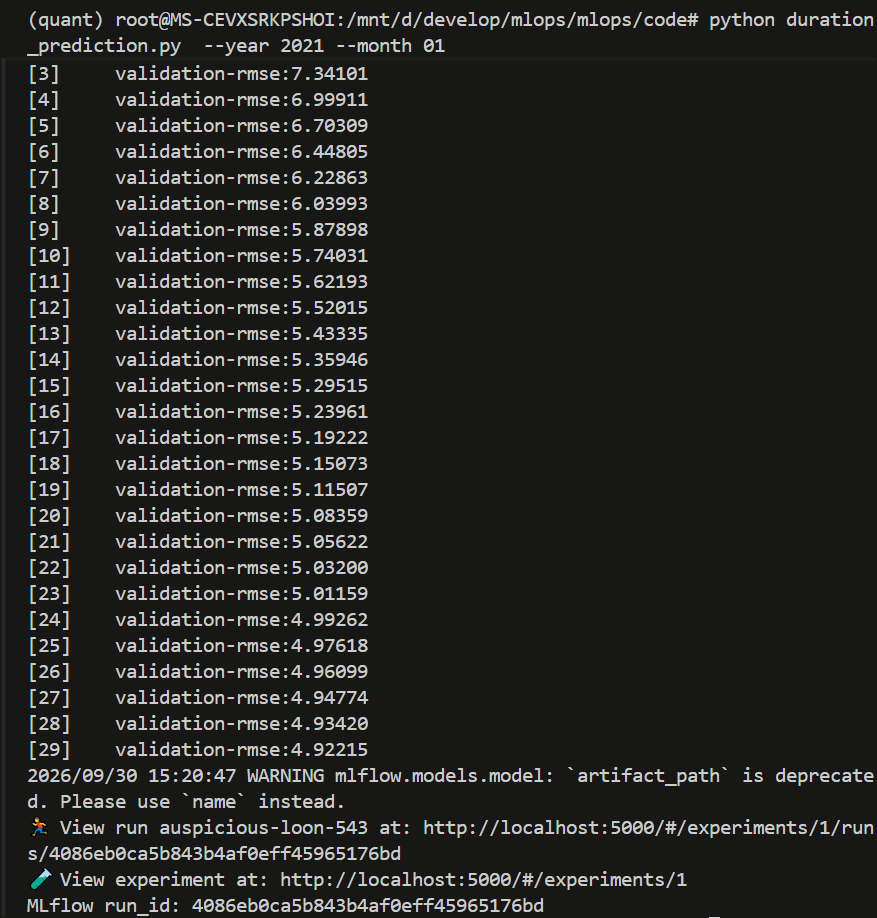

### - 该脚本现在是一个pipeline入口点。
### - An orchestrator 1个编排器，可以使用不同的周期调用它，安排其执行、重试或回填历史周期，而无需打开notebook。

## 五、 使用编排器  orchestrator

#### 上一个单元的Python脚本是一个可重复的任务。
#### 编排器将任务转化为一个受管理的工作流，包含调度、参数、重试和执行历史。
#### 编排器不是用来“让模型跑起来”的，它是用来解决多任务、有依赖、要定时、要重试、要追溯的场景。

### 1. 选择并运行工具  Choose and run a tool
- 常见的选择包括 Airflow 和 Prefect，其他选项还有 Dagster、Kestra 和 Mage。
- 首先选择与团队部署环境和学习目标相匹配的工具。
- 先在本地运行，然后创建一个简单的“Hello World”工作流，以便了解该工具如何表示任务、依赖关系以及执行流程。
- 在MLOps中，Apache Airflow 是目前应用最广泛、生态最成熟的编排器之一。

### 2. Orchestrate the training workflow    编排训练工作流
- 使用此模块中的代码，并将其步骤映射到具体任务中，确保数据流清晰明确。
- 下载选定的数据周期。  
- 转换并预处理特征。  
- 训练并评估模型。  
- 记录运行日志并保存生成的构建物。  
- 编排器应将周期参数传递给脚本，而不是修改脚本的源代码。例如，每月的计划任务可能在两个月前的数据上进行训练，并在上个月的数据上进行验证。
- 将日期作为 workflow 参数的一部分，以便运行历史中能够显示这些信息。

### 3. Backfill and deploy   回填并部署

- Backfill是指：对历史时期执行相同的workflow。
- 当数据积累后才引入pipline，或上游校正需要重新计算一段时间的月份时，Backfill非常有用。
- 在启动大规模Backfill前，应先在本地测试小范围的数据。
- 该单元的部署是可选的。
- 如果编排器将在云端运行，请保持本地工作流定义的可移植性，并记录其依赖项。
- 之前的批次包含使用 Prefect 和 Mage 的示例，可将其作为参考，而非假设必须使用某种编排器。

### one. 下载prefect

In [ ]:
# conda，虚拟环境中安装
pip install -U prefect   

In [ ]:
prefect version

In [2]:
!wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-03.parquet

--2026-09-30 20:36:39--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-03.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 13.35.218.227, 13.35.218.108, 13.35.218.179, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|13.35.218.227|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56127762 (54M) [binary/octet-stream]
Saving to: ‘yellow_tripdata_2023-03.parquet’

yellow_tripdata_202 100%[===================>]  53.53M  12.3MB/s    in 4.7s    

2026-09-30 20:36:44 (11.5 MB/s) - ‘yellow_tripdata_2023-03.parquet’ saved [56127762/56127762]



In [ ]:
# 移动到数据目录中去
mv yellow_tripdata_2023-03.parquet  data

In [7]:
import pandas as pd
df = pd.read_parquet("data/yellow_tripdata_2023-03.parquet")# 

In [8]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,3.403766e+06,3403766,3403766,3.316147e+06,3.403766e+06,3.316147e+06,3.403766e+06,3.403766e+06,3.403766e+06,3.403766e+06,3.403766e+06,3.403766e+06,3.403766e+06,3.403766e+06,3.403766e+06,3.403766e+06,3.316147e+06,3.316147e+06
mean,1.725320e+00,2023-03-16 11:32:30.578784,2023-03-16 11:49:23.487819,1.351417e+00,3.903871e+00,1.623961e+00,1.654540e+02,1.641003e+02,1.187310e+00,1.890845e+01,1.629128e+00,4.874393e-01,3.495237e+00,5.670059e-01,9.810640e-01,2.780343e+01,2.275176e+00,1.040236e-01
min,1.000000e+00,2001-01-01 00:06:49,2001-01-01 14:13:51,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.599000e+02,-7.500000e+00,-5.000000e-01,-8.000000e+01,-7.330000e+01,-1.000000e+00,-9.829500e+02,-2.500000e+00,-1.250000e+00
25%,1.000000e+00,2023-03-08 18:48:02,2023-03-08 19:04:47,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.570000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-03-16 12:18:33,2023-03-16 12:38:00,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.800000e+00,0.000000e+00,1.000000e+00,2.060000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-03-24 08:55:29.750000,2023-03-24 09:11:11.500000,1.000000e+00,3.380000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.120000e+01,2.500000e+00,5.000000e-01,4.340000e+00,0.000000e+00,1.000000e+00,2.976000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2023-04-05 20:17:42,2023-04-05 20:35:28,9.000000e+00,2.169870e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,2.100000e+03,1.375000e+01,4.000000e+00,9.843000e+02,1.770000e+02,1.000000e+00,2.100000e+03,2.500000e+00,1.250000e+00
std,4.588677e-01,NaN,NaN,8.861919e-01,1.916866e+02,7.358691e+00,6.373958e+01,6.967282e+01,5.334025e-01,1.825637e+01,1.842778e+00,1.020516e-01,3.996473e+00,2.121658e+00,1.892314e-01,2.286614e+01,7.745563e-01,3.503260e-01


In [10]:
def read_dataframe(filename):
    df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [11]:
df =  read_dataframe("data/yellow_tripdata_2023-03.parquet")

In [12]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,duration
count,3.316216e+06,3316216,3316216,3.231395e+06,3.316216e+06,3.231395e+06,3.316216e+06,3.316216e+06,3.316216e+06,3.316216e+06,3.316216e+06,3.316216e+06,3.316216e+06,3.316216e+06,3.231395e+06,3.231395e+06,3.316216e+06
mean,1.723023e+00,2023-03-16 11:27:41.238746,2023-03-16 11:42:41.236391,1.349379e+00,3.710452e+00,1.531373e+00,1.176428e+00,1.813107e+01,1.635718e+00,4.906224e-01,3.415902e+00,5.090149e-01,9.848481e-01,2.691308e+01,2.298608e+00,9.591910e-02,1.499996e+01
min,1.000000e+00,2002-12-31 23:10:19,2002-12-31 23:36:28,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-4.426000e+02,-7.500000e+00,-5.000000e-01,-8.000000e+01,-7.330000e+01,-1.000000e+00,-4.441000e+02,-2.500000e+00,-1.250000e+00,1.000000e+00
25%,1.000000e+00,2023-03-08 18:28:49.750000,2023-03-08 18:45:26,1.000000e+00,1.070000e+00,1.000000e+00,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.570000e+01,2.500000e+00,0.000000e+00,7.483333e+00
50%,2.000000e+00,2023-03-16 11:56:07.500000,2023-03-16 12:13:25,1.000000e+00,1.790000e+00,1.000000e+00,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.800000e+00,0.000000e+00,1.000000e+00,2.052000e+01,2.500000e+00,0.000000e+00,1.211667e+01
75%,2.000000e+00,2023-03-24 08:51:58,2023-03-24 09:05:58.250000,1.000000e+00,3.300000e+00,1.000000e+00,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.280000e+00,0.000000e+00,1.000000e+00,2.904000e+01,2.500000e+00,0.000000e+00,1.930000e+01
max,6.000000e+00,2023-04-05 20:17:42,2023-04-05 20:35:28,9.000000e+00,2.169870e+05,9.900000e+01,5.000000e+00,6.540000e+02,1.375000e+01,4.000000e+00,9.843000e+02,8.500000e+01,1.000000e+00,1.000000e+03,2.500000e+00,1.250000e+00,6.000000e+01
std,4.511494e-01,NaN,NaN,8.848749e-01,1.884433e+02,6.885674e+00,5.135607e-01,1.610079e+01,1.827005e+00,9.022861e-02,3.716096e+00,1.982643e+00,1.701809e-01,2.056570e+01,7.359179e-01,3.364625e-01,1.060465e+01


###  4、举个简单的例子，了解一下编排器的作用和使用方法

In [13]:
from prefect import flow

@flow
def my_workflow():
    print("Hello, Prefect!")

if __name__ == "__main__":
    my_workflow()

22:11:12.258 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8684
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

22:11:32.432 | ERROR   | docket.dependencies - ↩ [   554ms] send_telemetry_heartbeat(){send_telemetry_heartbeat}
Traceback (most recent call last):
  File "/root/miniconda3/envs/quant/lib/python3.11/site-packages/sqlalchemy/engine/base.py", line 1943, in _exec_single_context
    self.dialect.do_execute(
  File "/root/miniconda3/envs/quant/lib/python3.11/site-packages/sqlalchemy/engine/default.py", line 1180, in do_execute
    cursor.execute(statement, parameters)
  File "/root/miniconda3/envs/quant/lib/python3.11/site-packages/sqlalchemy/connectors/asyncio.py", line 258, in execute
    self._adapt_connection._handle_exception(error)
  File "/root/miniconda3/envs/quant/lib/python3.11/site-packages/sqlalchemy/connectors/asyncio.py", line 412, in _handle_exception
    self._handle_exception_no_connection(self.dbapi, error)
  File "/root/miniconda3/envs/quant/lib/python3.11/site-packages/sqlalchemy/dialects/sqlite/aiosqlite.py", line 237, in _handle_exception_no_connection
    super()._han

22:11:34.669 | INFO    | Flow run 'gigantic-shoebill' - Beginning flow run 'gigantic-shoebill' for flow 'my-workflow'

Hello, Prefect!


22:11:35.693 | INFO    | Flow run 'gigantic-shoebill' - Finished in state Completed()

In [2]:
from prefect import flow, task

@task
def extract():
    return "数据"

@task
def transform(data):
    return data + " 已处理"

@flow
def etl_pipeline():
    raw = extract()
    result = transform(raw)
    print(result)

if __name__ == "__main__":
    etl_pipeline()

08:55:40.552 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8017
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

08:56:02.976 | INFO    | Flow run 'opal-sunfish' - Beginning flow run 'opal-sunfish' for flow 'etl-pipeline'

08:56:03.003 | INFO    | Task run 'extract-fb4' - Finished in state Completed()

08:56:03.018 | INFO    | Task run 'transform-f65' - Finished in state Completed()

数据 已处理


08:56:03.999 | INFO    | Flow run 'opal-sunfish' - Finished in state Completed()

In [ ]:
# 我们从日志，可以看到，prefect启动了1个临时的服务，
# 经过观察，发现，脚本跑完，服务不会自动退出，需要手动杀掉，否则下一次启动 临时的prefect  server服务，可能会报端口错误
pkill -9 -f "prefect.server.api.server"

## 5. 我们自己搞1个编排器的使用案例

In [ ]:
# 代码

import pandas as pd
import xgboost as xgb
import mlflow
from prefect import flow, task
from sklearn.metrics import root_mean_squared_error
from sklearn.feature_extraction import DictVectorizer
import pickle
from pathlib import Path


mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("nyc-taxi-experiment")

# ---------- Task 1: 读取数据 ----------
@task
def read_data(year: int, month: int):
    url = f'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month:02d}.parquet'
    df = pd.read_parquet(url)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)

    return df

# ---------- Task 2: 特征工程 ----------
@task
def create_features(df: pd.DataFrame, dv: DictVectorizer = None):
    df['PU_DO'] = df['PULocationID'] + '_' + df['DOLocationID']
    categorical = ['PU_DO']
    numerical = ['trip_distance']

    train_dicts = df[categorical + numerical].to_dict(orient='records')

    if dv is None:
        dv = DictVectorizer()
        X = dv.fit_transform(train_dicts)
    else:
        X = dv.transform(train_dicts)

    y = df['duration'].values
    return X, y, dv

# ---------- Task 3: 训练模型 ----------
@task
def train_model(X_train, y_train, X_val, y_val, dv):
    with mlflow.start_run() as run:
        train = xgb.DMatrix(X_train, label=y_train)
        valid = xgb.DMatrix(X_val, label=y_val)

        best_params = {
            'learning_rate': 0.09585355369315604,
            'max_depth': 20,
            'min_child_weight': 1.060597050922164,
            'objective': 'reg:squarederror',
            'reg_alpha': 0.018060244040060163,
            'reg_lambda': 0.011658731377413597,
            'seed': 42
        }

        mlflow.log_params(best_params)

        booster = xgb.train(
            params=best_params,
            dtrain=train,
            num_boost_round=50,
            evals=[(valid, 'validation')],
            early_stopping_rounds=5
        )

        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

        Path("models").mkdir(exist_ok=True)
        with open("models/preprocessor.b", "wb") as f_out:
            pickle.dump(dv, f_out)
        mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

        mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

        return run.info.run_id

# ---------- Flow: 串联所有 Task ----------
@flow
def training_pipeline(year: int, month: int):
    # 1. 读训练数据
    df_train = read_data(year, month)

    # 2. 立刻做特征工程，然后释放 df_train
    X_train, y_train, dv = create_features(df_train)
    del df_train

    # 3. 读验证数据
    df_val = read_data(year, month + 1) if month < 12 else read_data(year + 1, 1)

    # 4. 用训练集的 dv 处理验证集，然后释放 df_val
    X_val, y_val, _ = create_features(df_val, dv)
    del df_val

    # 5. 训练模型
    run_id = train_model(X_train, y_train, X_val, y_val, dv)
    print(f"训练完成，MLflow run_id: {run_id}")

if __name__ == "__main__":
    training_pipeline(2021, 1)

### 测试一下，跑起来

In [ ]:
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/mlops/code# python prefect_Orchestration_example.py 
13:38:35.002 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8170
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.
13:38:49.279 | INFO    | Flow run 'hissing-chachalaca' - Beginning flow run 'hissing-chachalaca' for flow 'training-pipeline'
13:38:51.926 | INFO    | Task run 'read_data-036' - Finished in state Completed()
13:38:58.331 | INFO    | Task run 'create_features-49b' - Finished in state Completed()
13:39:01.453 | INFO    | Task run 'read_data-aa9' - Finished in state Completed()
13:39:08.029 | INFO    | Task run 'create_features-78a' - Finished in state Completed()
[0]     validation-rmse:8.71074
[1]     validation-rmse:8.19881
[2]     validation-rmse:7.75156
[3]     validation-rmse:7.36256
[4]     validation-rmse:7.02513
[5]     validation-rmse:6.73288
[6]     validation-rmse:6.48160
[7]     validation-rmse:6.26581
[8]     validation-rmse:6.08070
[9]     validation-rmse:5.92138
[10]    validation-rmse:5.78587
[11]    validation-rmse:5.67004
[12]    validation-rmse:5.57124
[13]    validation-rmse:5.48606
[14]    validation-rmse:5.41350
[15]    validation-rmse:5.35158
[16]    validation-rmse:5.29794
[17]    validation-rmse:5.25141
[18]    validation-rmse:5.21129
[19]    validation-rmse:5.17707
[20]    validation-rmse:5.14693
[21]    validation-rmse:5.12072
[22]    validation-rmse:5.09778
[23]    validation-rmse:5.07750
[24]    validation-rmse:5.05961
[25]    validation-rmse:5.04312
[26]    validation-rmse:5.02868
[27]    validation-rmse:5.01580
[28]    validation-rmse:5.00385
[29]    validation-rmse:4.99294
[30]    validation-rmse:4.98377
[31]    validation-rmse:4.97478
[32]    validation-rmse:4.96705
[33]    validation-rmse:4.95928
[34]    validation-rmse:4.95236
[35]    validation-rmse:4.94588
[36]    validation-rmse:4.94054
[37]    validation-rmse:4.93508
[38]    validation-rmse:4.92910
[39]    validation-rmse:4.92377
[40]    validation-rmse:4.91959
[41]    validation-rmse:4.91466
[42]    validation-rmse:4.91090
[43]    validation-rmse:4.90692
[44]    validation-rmse:4.90349
[45]    validation-rmse:4.89985
[46]    validation-rmse:4.89688
[47]    validation-rmse:4.89314
[48]    validation-rmse:4.89066
[49]    validation-rmse:4.88732
2026/10/01 13:42:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🏃 View run adorable-rat-510 at: http://localhost:5000/#/experiments/1/runs/adef29c02b1d4dd781978ba4e90b5ca4
🧪 View experiment at: http://localhost:5000/#/experiments/1
13:42:44.909 | INFO    | Task run 'train_model-b7f' - Finished in state Completed()
训练完成，MLflow run_id: adef29c02b1d4dd781978ba4e90b5ca4
13:42:45.642 | INFO    | Flow run 'hissing-chachalaca' - Finished in state Completed()
13:42:45.663 | INFO    | prefect - Stopping temporary server on http://127.0.0.1:8170

### 现在的 training_pipeline(2020, 1)，是手动跑一次。这时候 Prefect 的作用，确实跟“在 Python 里加几个 print”差不多。
### 单次运行，看不出编排器的价值；多次运行、定时运行、失败重试、回填历史，才是它的主场。